# FixBikeViz first results

@anastassiavybornova

Visualization of the top X gaps resulting from the current MVP for the following user-defined parameters:

```python
city_name = 'Copenhagen Municipality' # used for Overpass API query
proj_crs = "EPSG:25832"

radius = 2000 # in meters; used to cut-off paths for betweenness centrality compute
maxgap = 50 # in meters; maximum distance between node pairs to be considered as potential gap
penalty = {
    0: 5,
    1: 1
} # factor by which length is multiplied to get weight for NONprotected edges
```

In [1]:
# import packages
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import pickle
import contextily as cx
from shapely.geometry import LineString

In [2]:
proj_crs = "EPSG:25832"
maxgap = 50

In [3]:
# read in data
with open("./data/G.pickle", "rb") as handle:
    G = pickle.load(handle)
nodes_gdf = gpd.read_file("./data/nodes_gdf.gpkg")
edges_gdf = gpd.read_file("./data/edges_gdf.gpkg")
with open("./data/df.json", "r") as file:
    df = pd.DataFrame.from_dict(json.load(file))

## issues to solve:

- [ ] in MVP: figure out where geom attribute gets lost; then make sure all G.edges have a geometry attribute
- [x] in MVP: make sure to save pbi 0/1 classification as column of edge_gdf
- [ ] in VIZ: add pbi 0/1 distinction to plotting
- [ ] in VIZ: fix zoom level to always get YxY m (dep on maxgap) around gap centroid
- [ ] in VIZ: fix to display in interactive folium map
- [ ] in VIZ: explore overlaps of gaps

In [4]:
# assuming that if an edge geometry is missing, then it is simply the straight line between its 2 nodes:
def get_edge_geometry(G, edge, nodes_gdf):
    try:
        geom = G.edges[edge]["geometry"]
    except:
        geom = LineString(
            [
                nodes_gdf[nodes_gdf["osmid"]==edge[0]].geometry.values[0],
                nodes_gdf[nodes_gdf["osmid"]==edge[1]].geometry.values[0],
            ]
        )
    return geom

/var/folders/q4/95x26cls17s1z694v56lw3hh0000gn/T/ipykernel_62426/2585542112.py:17: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  edges_gdf[edges_gdf.intersects(gap_gdf.union_all())].plot(ax=ax, color = "black", zorder = 1, lw = 0)
/Users/jqz304/miniconda3/envs/growbikenet/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 38 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


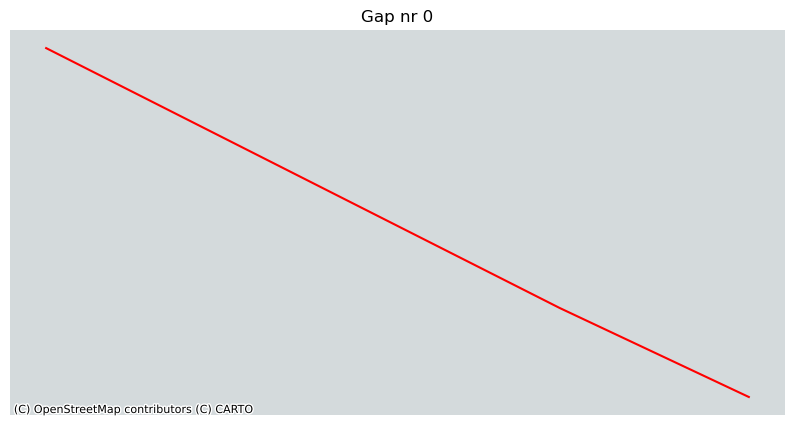

/var/folders/q4/95x26cls17s1z694v56lw3hh0000gn/T/ipykernel_62426/2585542112.py:17: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  edges_gdf[edges_gdf.intersects(gap_gdf.union_all())].plot(ax=ax, color = "black", zorder = 1, lw = 0)
/Users/jqz304/miniconda3/envs/growbikenet/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 39 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


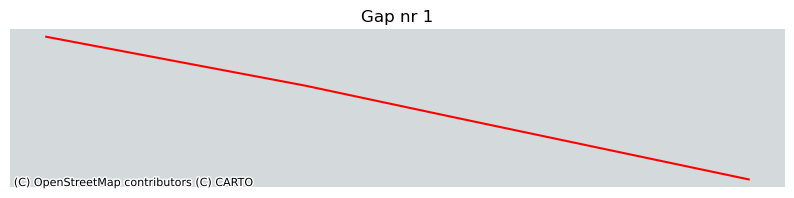

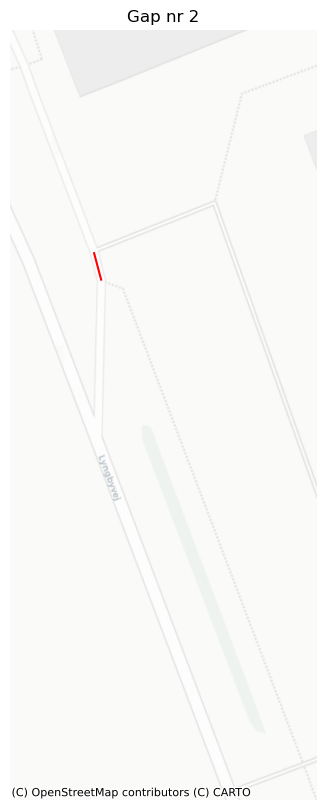

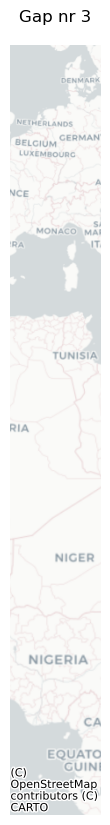

/var/folders/q4/95x26cls17s1z694v56lw3hh0000gn/T/ipykernel_62426/2585542112.py:17: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  edges_gdf[edges_gdf.intersects(gap_gdf.union_all())].plot(ax=ax, color = "black", zorder = 1, lw = 0)
/Users/jqz304/miniconda3/envs/growbikenet/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 39 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


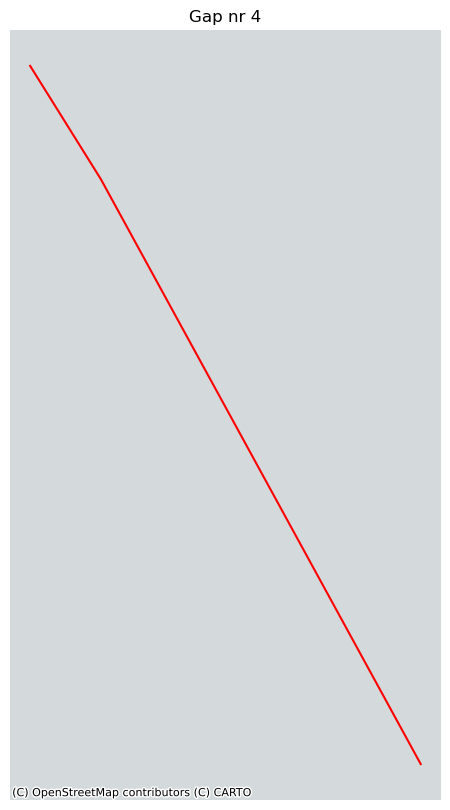

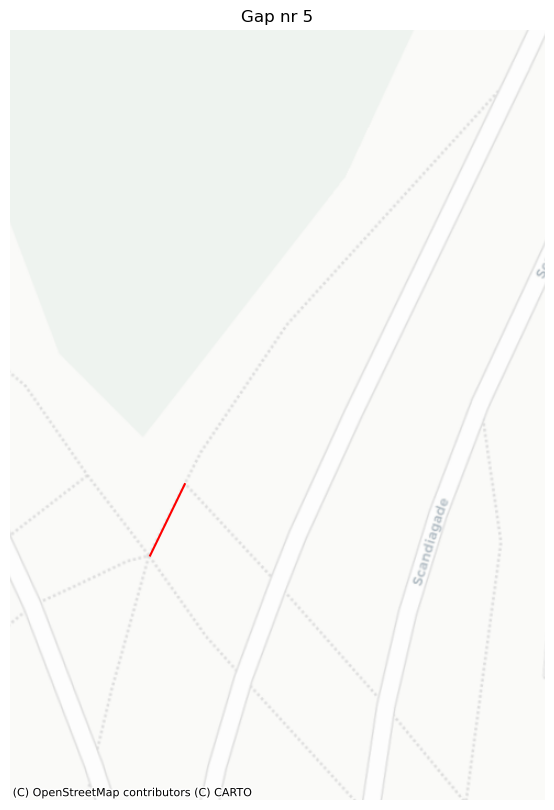

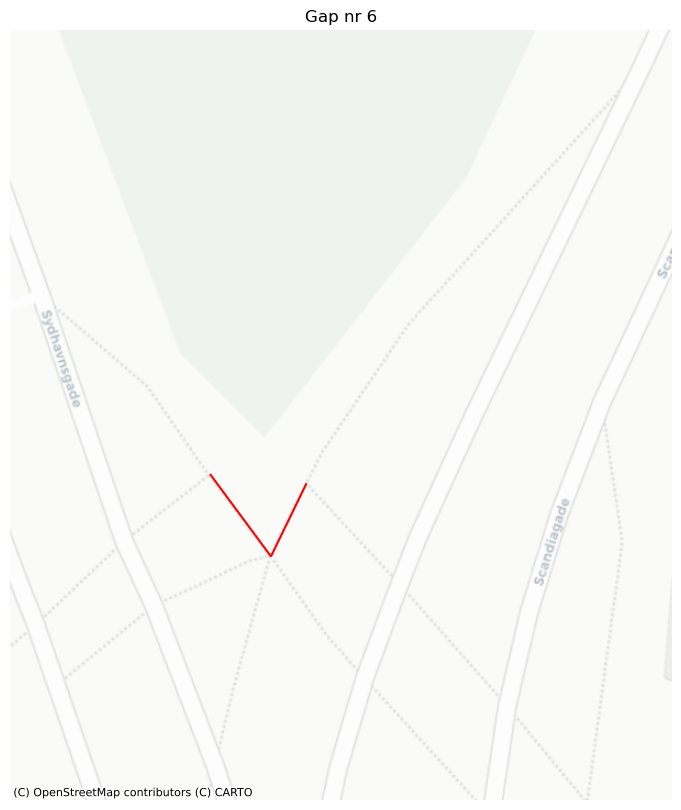

/Users/jqz304/miniconda3/envs/growbikenet/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 21 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


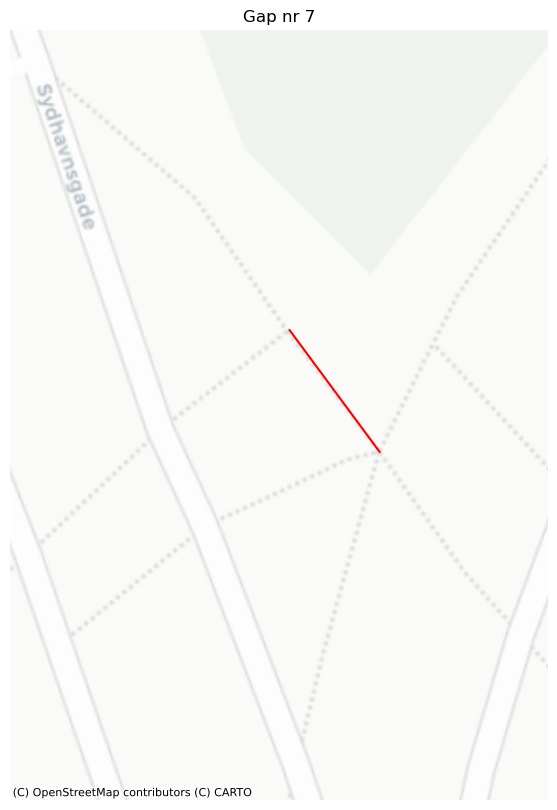

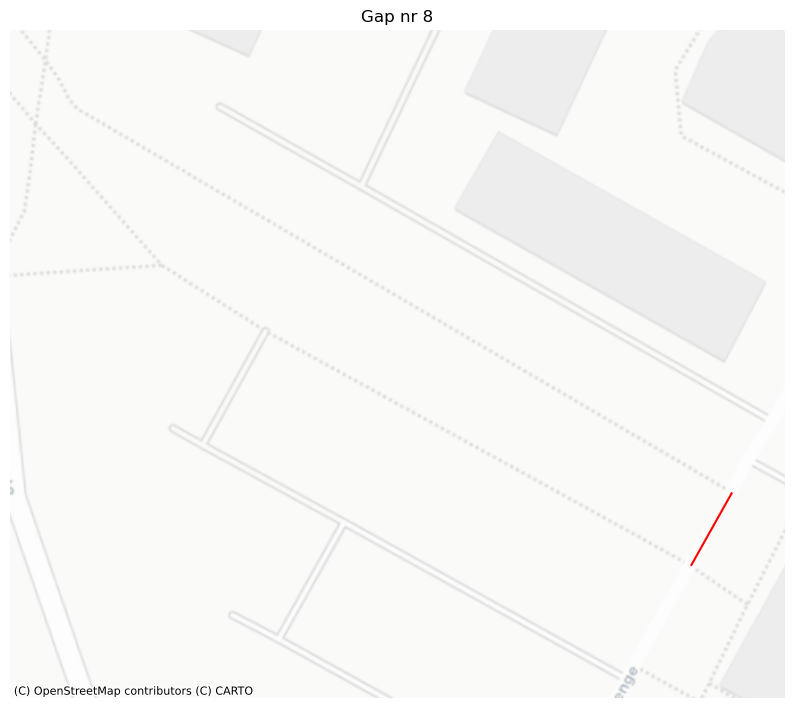

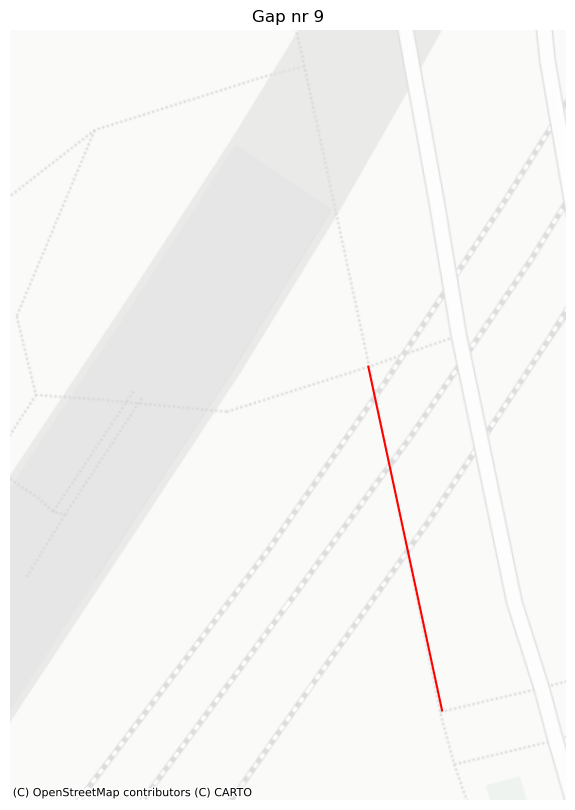

/Users/jqz304/miniconda3/envs/growbikenet/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 21 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


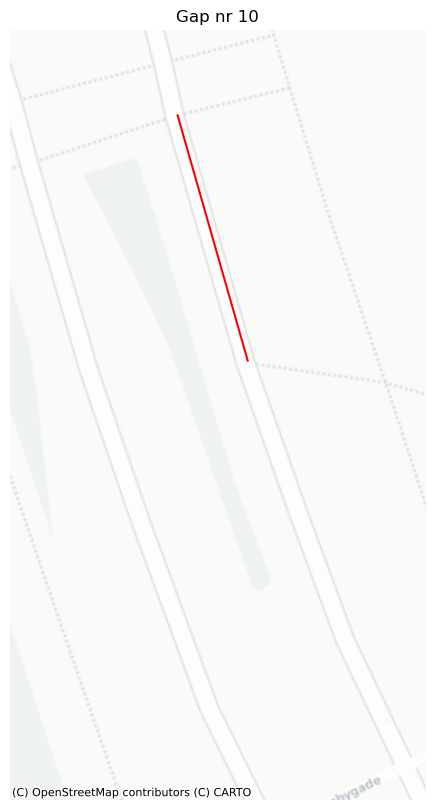

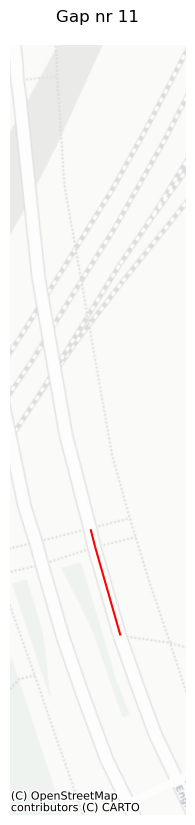

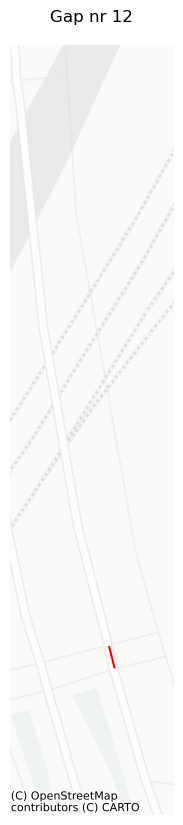

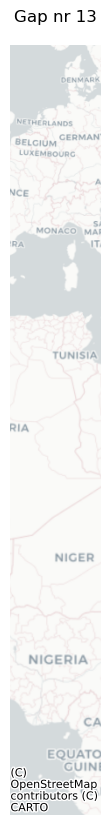

/var/folders/q4/95x26cls17s1z694v56lw3hh0000gn/T/ipykernel_62426/2585542112.py:17: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  edges_gdf[edges_gdf.intersects(gap_gdf.union_all())].plot(ax=ax, color = "black", zorder = 1, lw = 0)
/Users/jqz304/miniconda3/envs/growbikenet/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 38 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


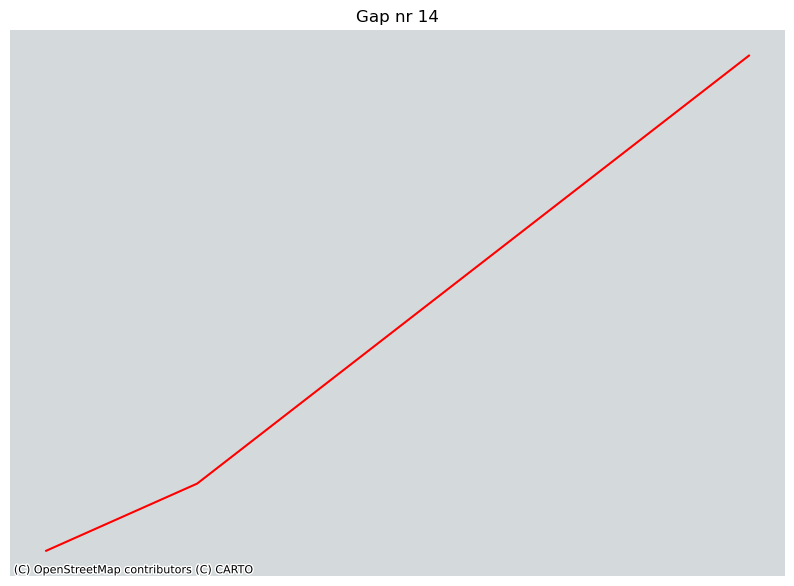

/var/folders/q4/95x26cls17s1z694v56lw3hh0000gn/T/ipykernel_62426/2585542112.py:17: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  edges_gdf[edges_gdf.intersects(gap_gdf.union_all())].plot(ax=ax, color = "black", zorder = 1, lw = 0)
/Users/jqz304/miniconda3/envs/growbikenet/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 38 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


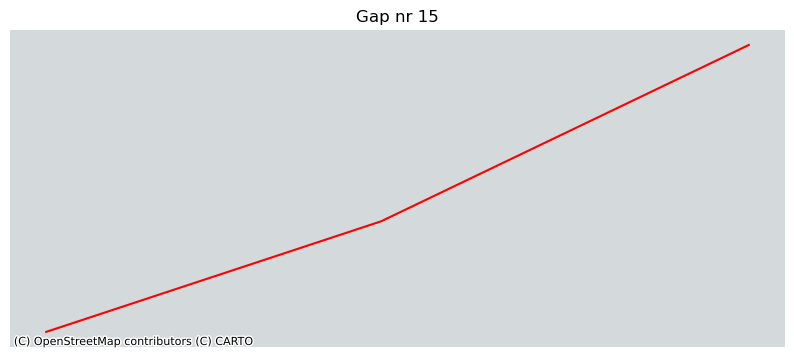

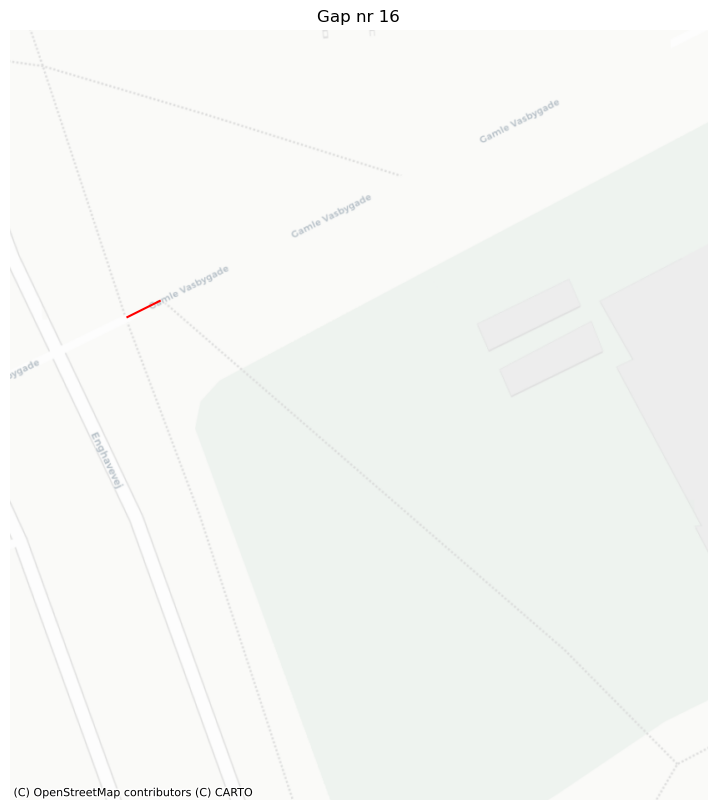

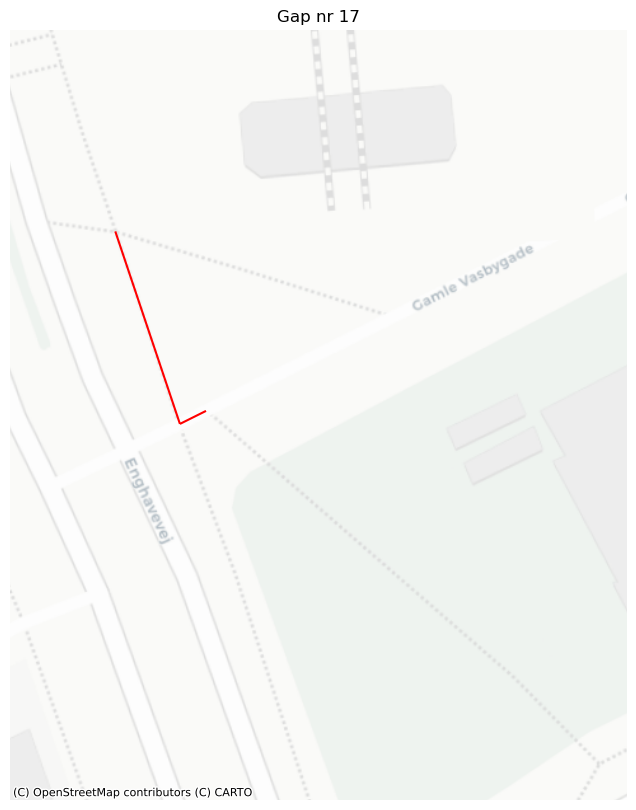

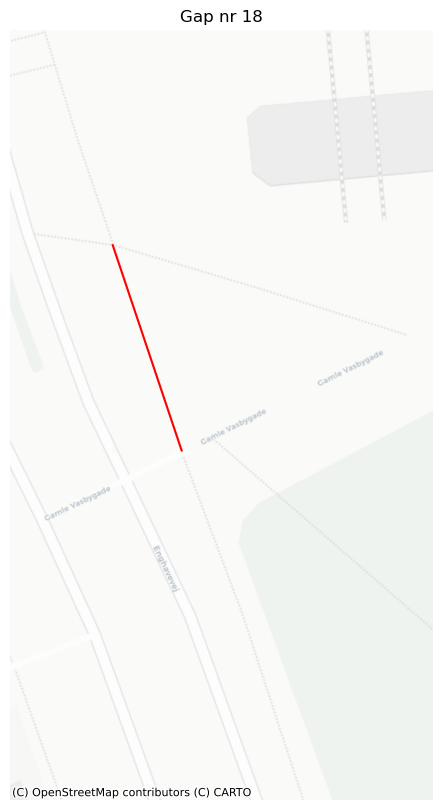

/var/folders/q4/95x26cls17s1z694v56lw3hh0000gn/T/ipykernel_62426/2585542112.py:17: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  edges_gdf[edges_gdf.intersects(gap_gdf.union_all())].plot(ax=ax, color = "black", zorder = 1, lw = 0)
/Users/jqz304/miniconda3/envs/growbikenet/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 39 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


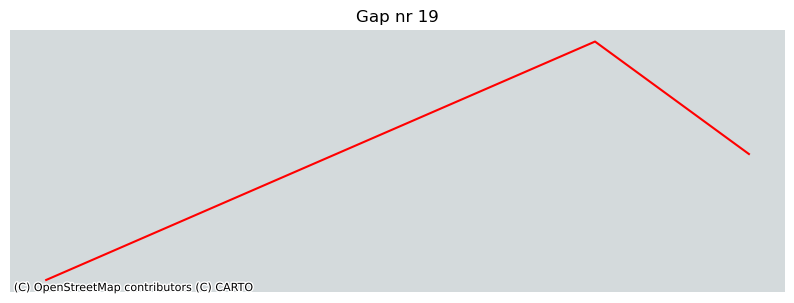

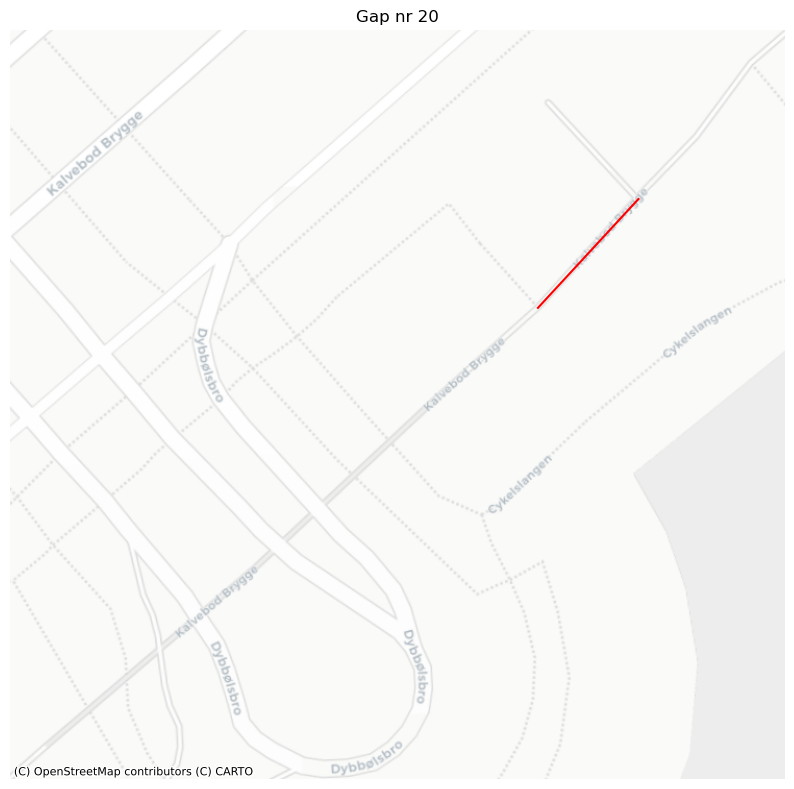

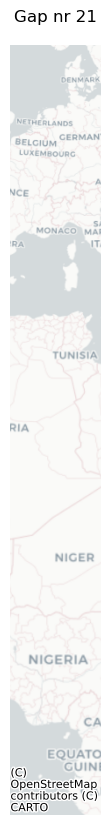

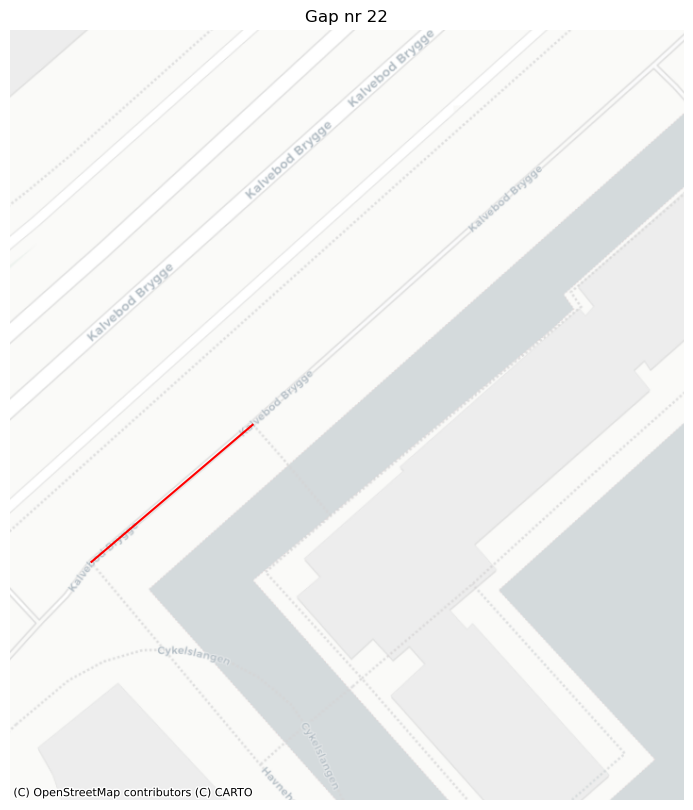

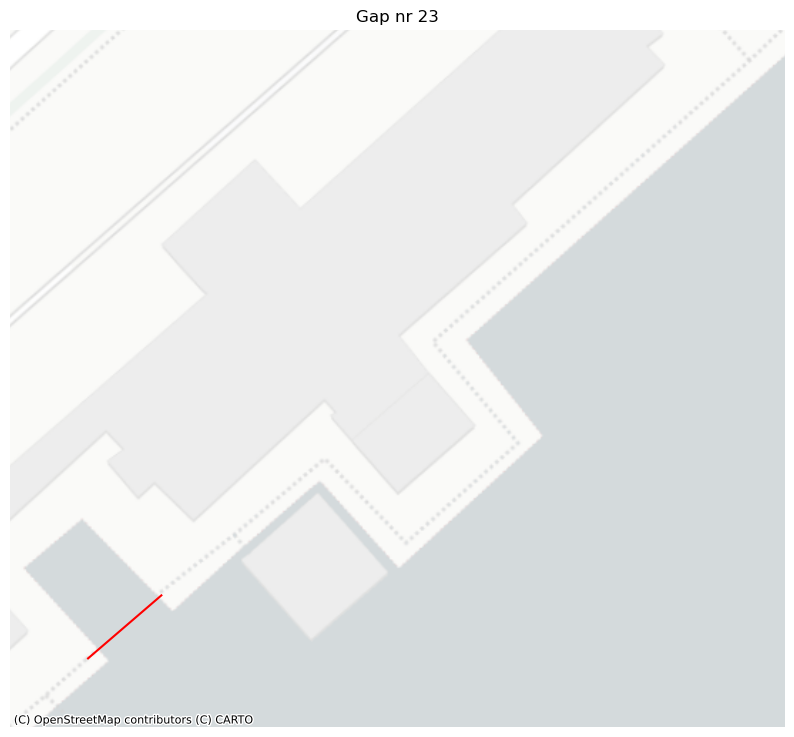

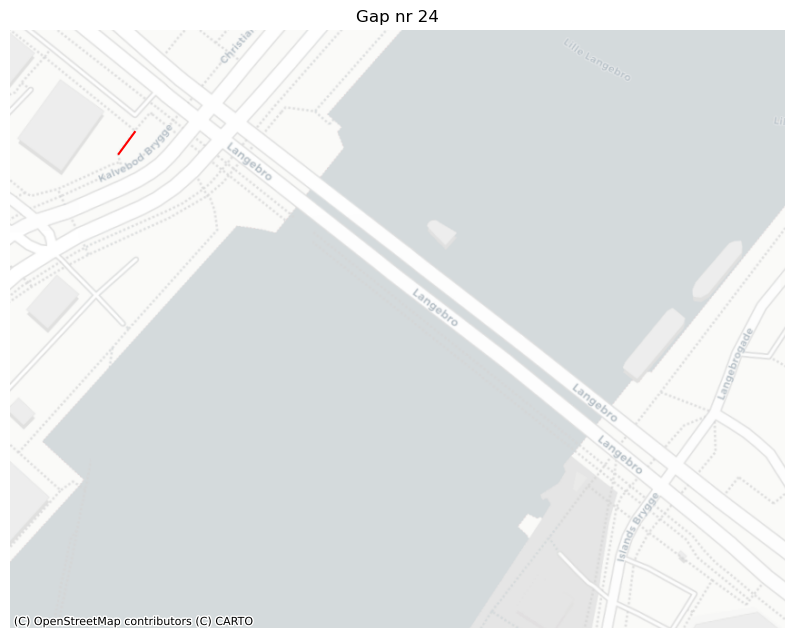

/Users/jqz304/miniconda3/envs/growbikenet/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 21 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


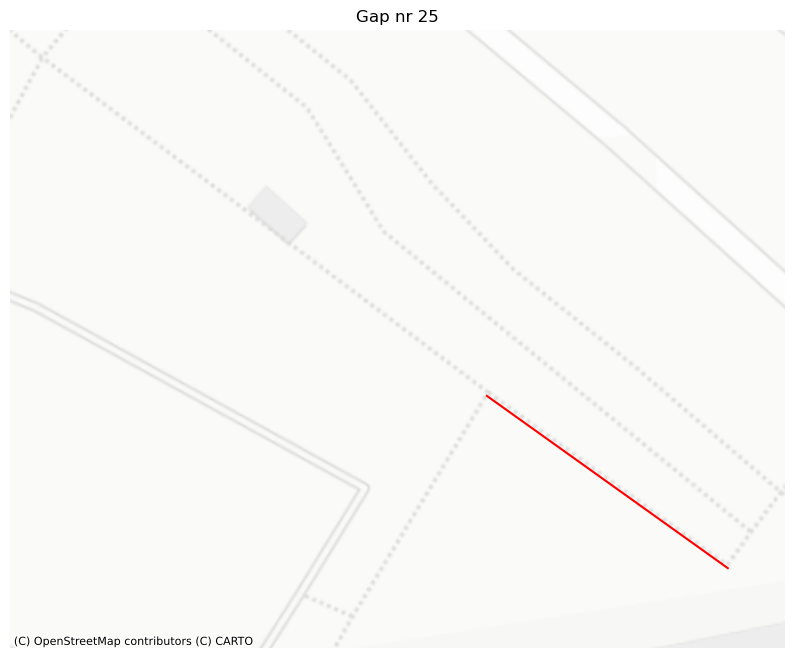

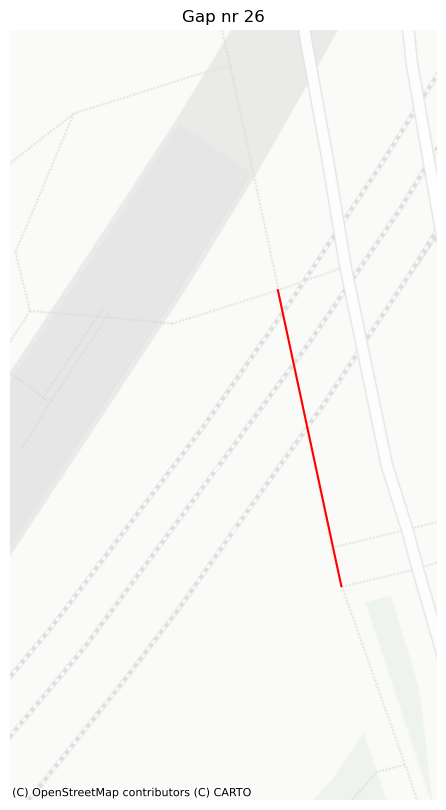

/var/folders/q4/95x26cls17s1z694v56lw3hh0000gn/T/ipykernel_62426/2585542112.py:17: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  edges_gdf[edges_gdf.intersects(gap_gdf.union_all())].plot(ax=ax, color = "black", zorder = 1, lw = 0)
/Users/jqz304/miniconda3/envs/growbikenet/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 40 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


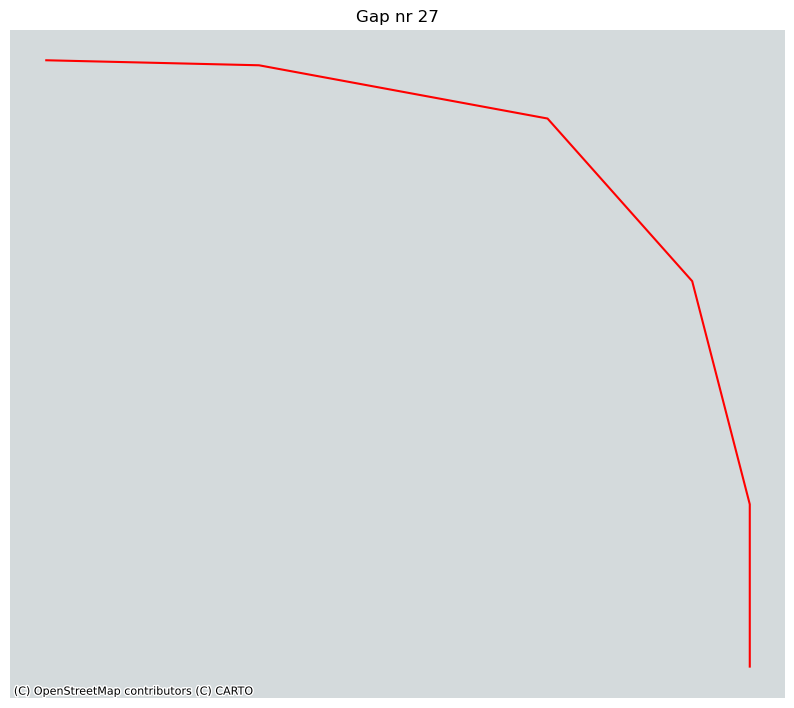

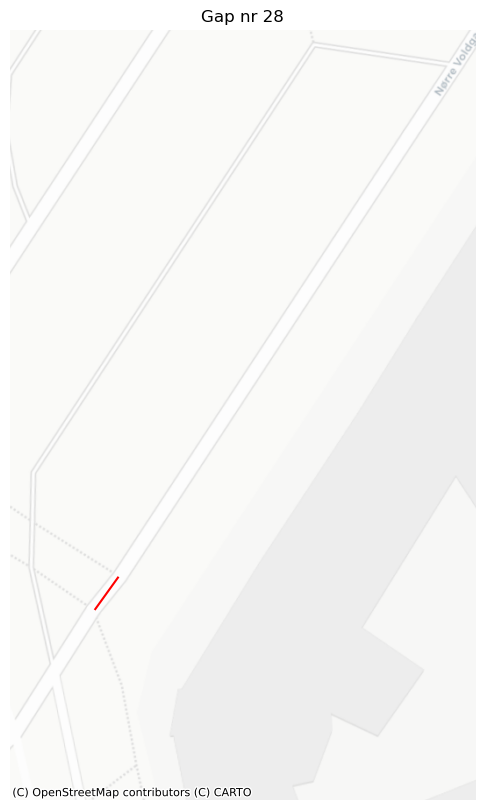

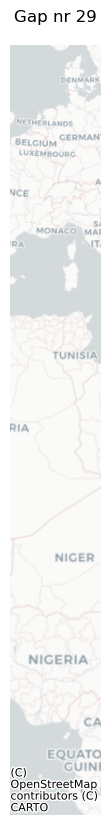

/var/folders/q4/95x26cls17s1z694v56lw3hh0000gn/T/ipykernel_62426/2585542112.py:17: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  edges_gdf[edges_gdf.intersects(gap_gdf.union_all())].plot(ax=ax, color = "black", zorder = 1, lw = 0)
/Users/jqz304/miniconda3/envs/growbikenet/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 39 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


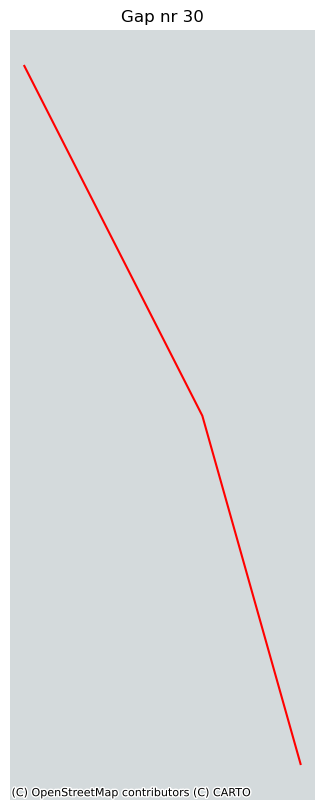

/var/folders/q4/95x26cls17s1z694v56lw3hh0000gn/T/ipykernel_62426/2585542112.py:17: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  edges_gdf[edges_gdf.intersects(gap_gdf.union_all())].plot(ax=ax, color = "black", zorder = 1, lw = 0)
/Users/jqz304/miniconda3/envs/growbikenet/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 39 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


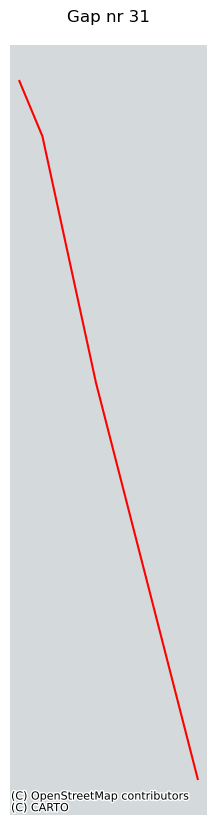

/var/folders/q4/95x26cls17s1z694v56lw3hh0000gn/T/ipykernel_62426/2585542112.py:17: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  edges_gdf[edges_gdf.intersects(gap_gdf.union_all())].plot(ax=ax, color = "black", zorder = 1, lw = 0)
/Users/jqz304/miniconda3/envs/growbikenet/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 40 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


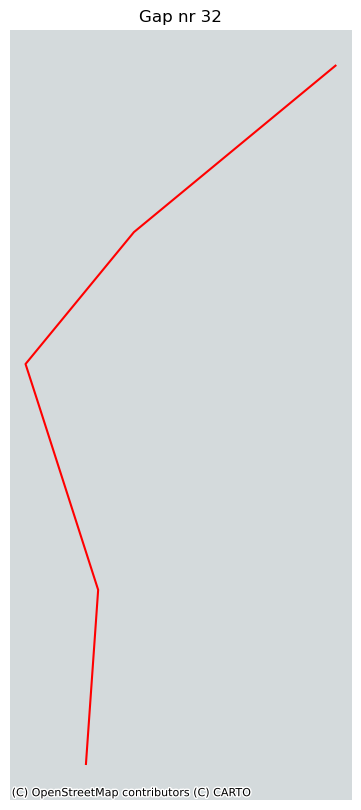

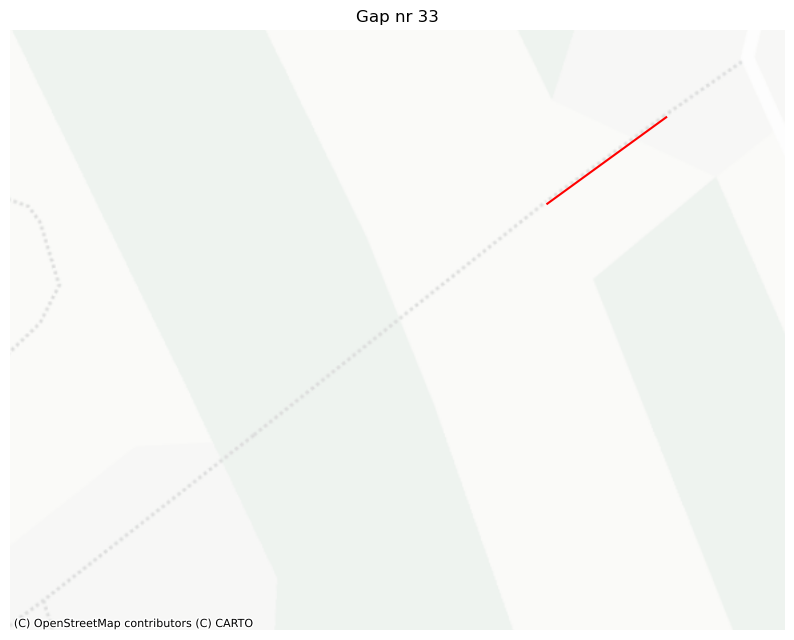

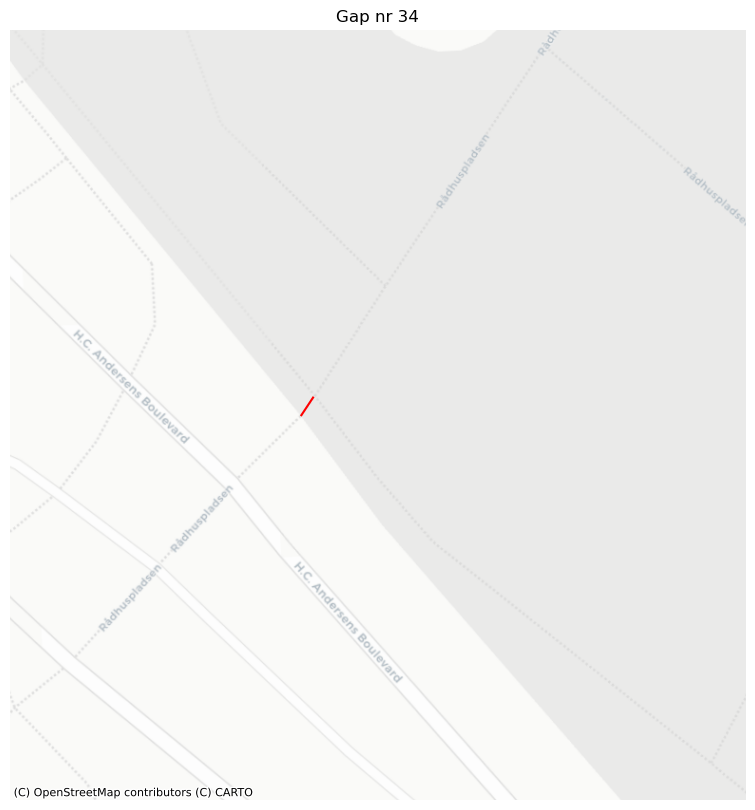

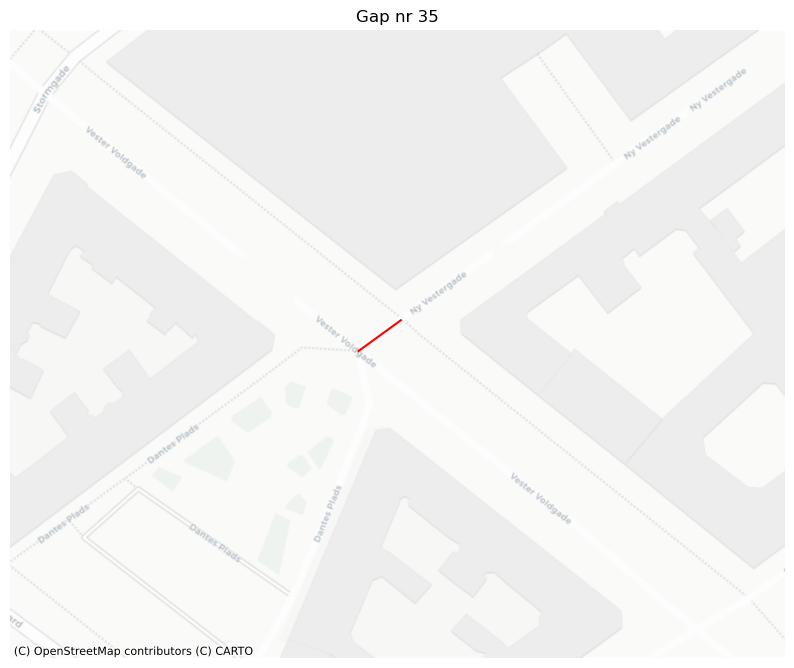

/var/folders/q4/95x26cls17s1z694v56lw3hh0000gn/T/ipykernel_62426/2585542112.py:17: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  edges_gdf[edges_gdf.intersects(gap_gdf.union_all())].plot(ax=ax, color = "black", zorder = 1, lw = 0)
/Users/jqz304/miniconda3/envs/growbikenet/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 37 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


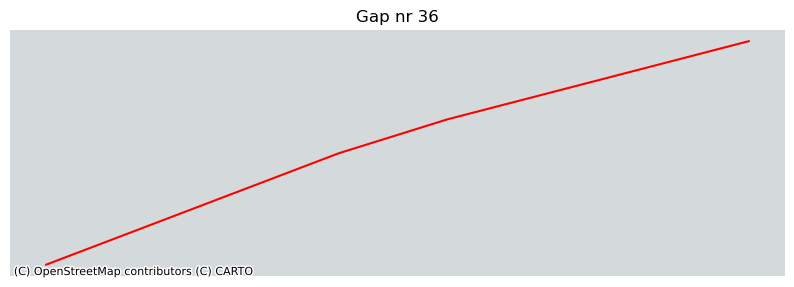

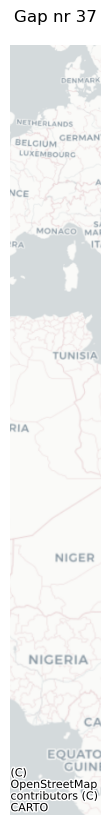

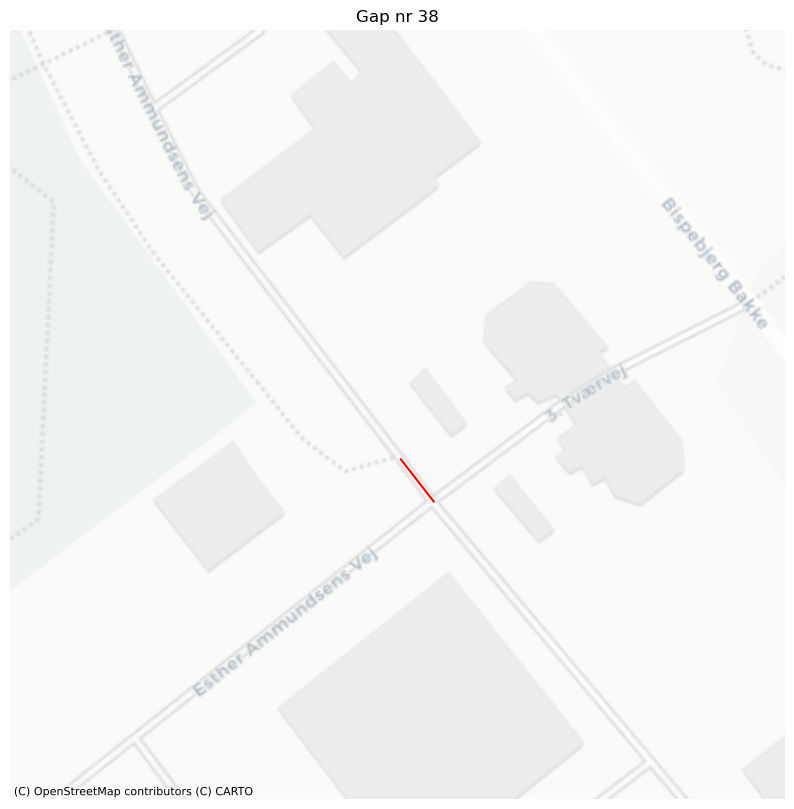

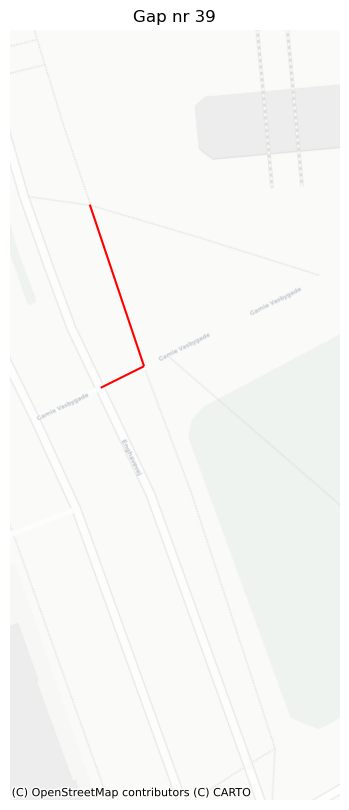

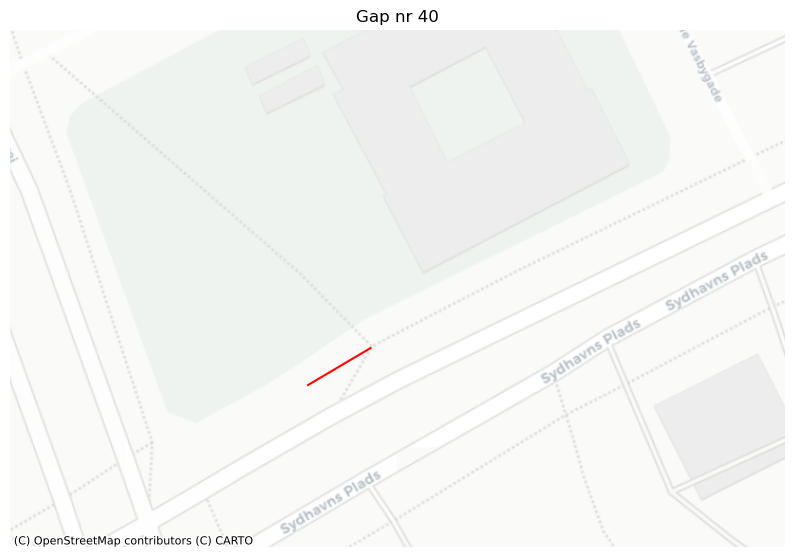

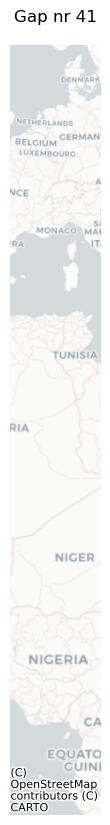

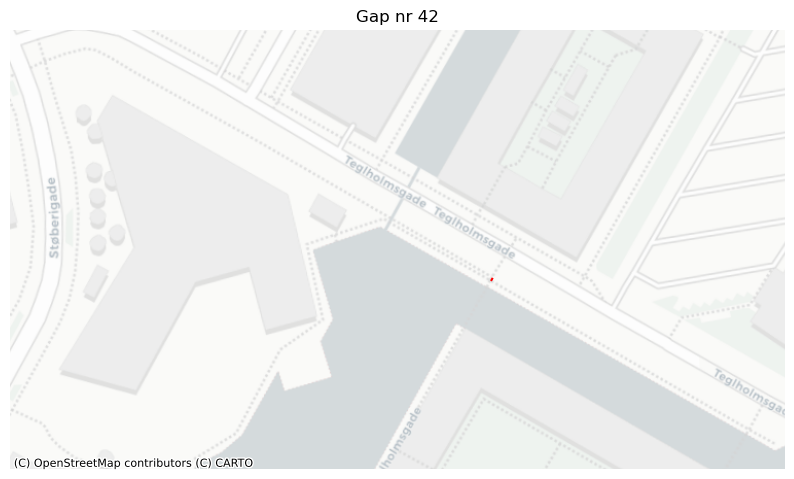

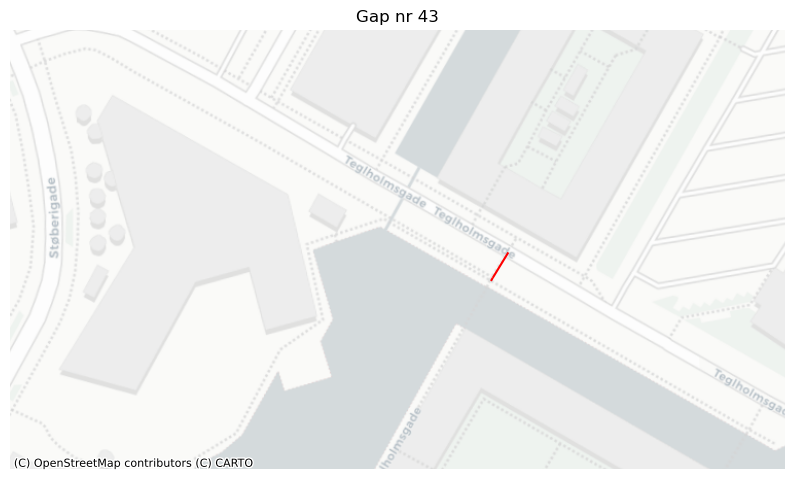

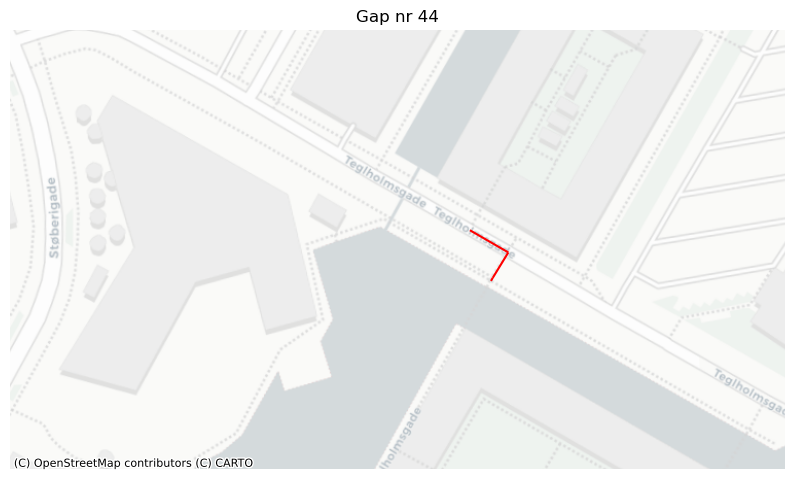

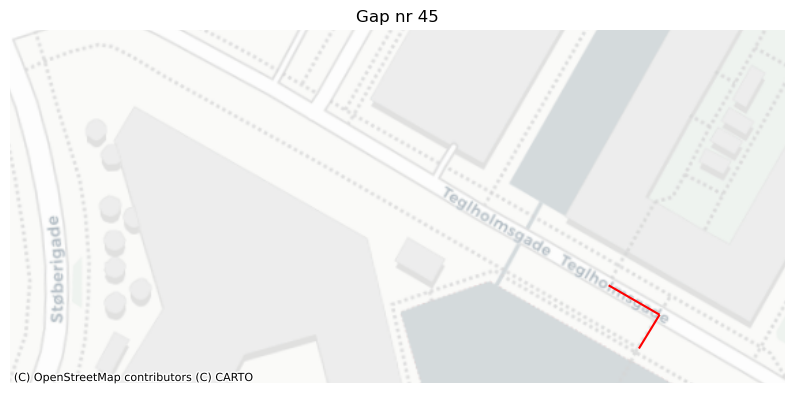

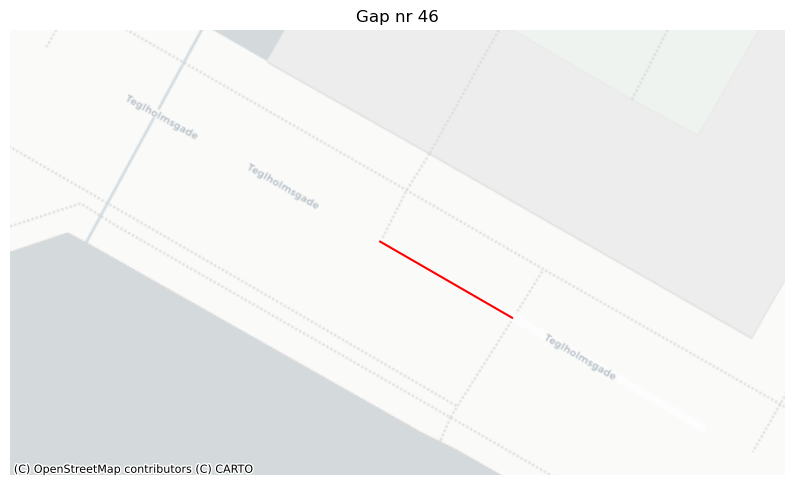

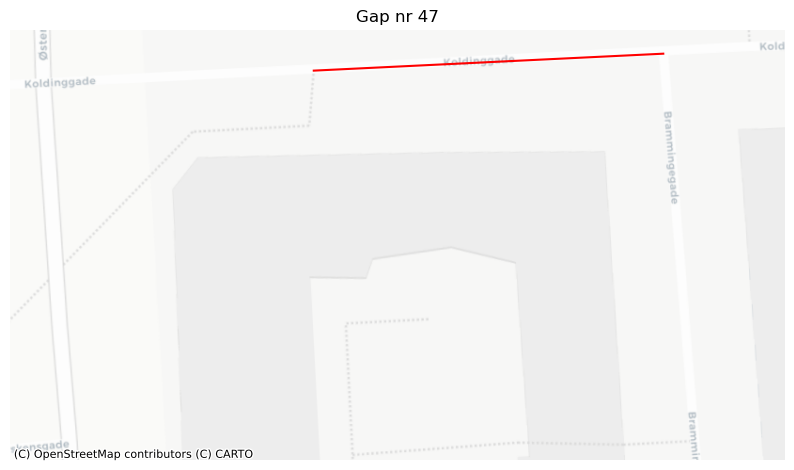

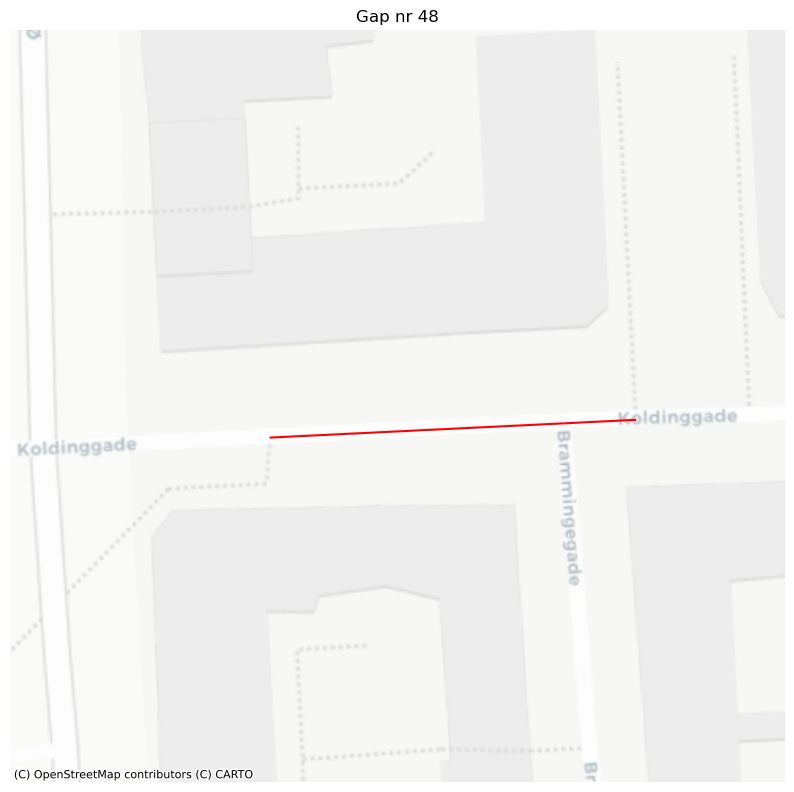

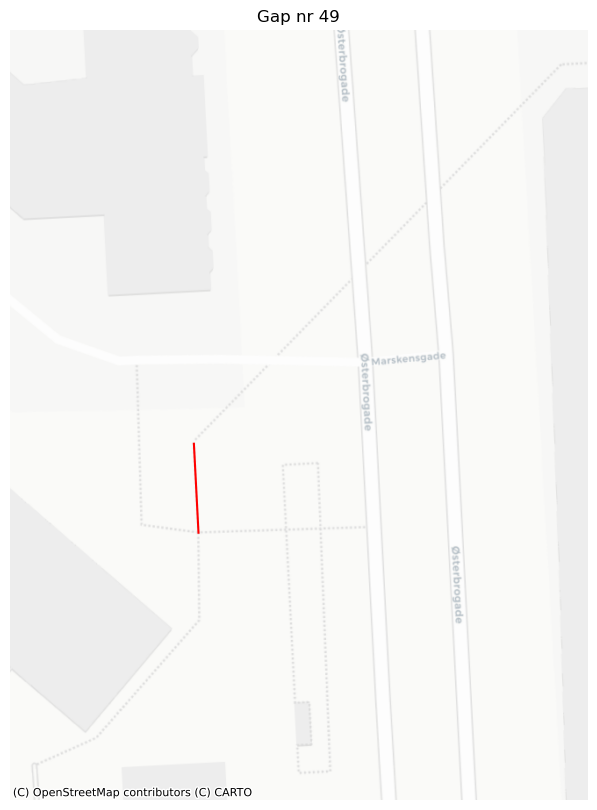

In [5]:
for gap in range(50):
    fig, ax = plt.subplots(1,1, figsize=(10,10))

    gap_gdf = gpd.GeoDataFrame(
        {
            "geometry": [
                get_edge_geometry(
                    G,
                    z,
                    nodes_gdf
                ) for z in zip(df.iloc[gap].nodelist, df.iloc[gap].nodelist[1:])]
        },
        crs = proj_crs
    )

    gap_gdf.plot(ax=ax, color = "red", zorder = 2)
    edges_gdf[edges_gdf.intersects(gap_gdf.union_all())].plot(ax=ax, color = "black", zorder = 1, lw = 0)
    cx.add_basemap(ax=ax, crs = proj_crs, source=cx.providers.CartoDB.Positron)
    ax.set_axis_off()
    ax.set_title(f"Gap nr {gap}")
    plt.show()